# 📓 FinSight: An Agentic AI for Investment Research   

##Group 11 - Kiran Joseph,Paul Itoopunny,Bashir Ali

## This project builds FinSight, an autonomous AI agent designed to conduct comprehensive investment research.

## The agent's architecture is based on modern agentic principles, including dynamic tool use, self-reflection, and multi-step workflow patterns. This notebook walks through each component, from the agent's "specialist" tools to its core "brain" and reasoning loop. bold text

## 🛠️ The FinSight Tool Stack
Our agent uses a set of specialized tools to gather and analyze data:

### AI Core
**Google Gemini 2.5 flash**: The "brain" that plans, analyzes, and critiques. It powers both the Analyst and Evaluator agents.

### Financial Data
**Yahoo Finance (yfinance)**: Provides all core financial ratios, company info, and historical stock prices.

**Financial Modeling Prep (FMP)**: Used to find a list of competitor companies.

### News & Sentiment
**NewsAPI**: Fetches the latest news articles for a company.

**Hugging Face FinBERT**: A sentiment analysis model that classifies news headlines as positive, negative, or neutral.

### Analysis & Visualization
**Pandas TA (pandas_ta)**: Quickly calculates technical indicators like RSI, MACD, and EMAs.

**Matplotlib Finance (mplfinance)**: Creates the final, professional-looking stock charts.

In [ ]:
!pip install -q google-generativeai yfinance pandas_ta requests transformers torch mplfinance  ## Install required libraries

In [21]:
# Cell 2: Imports and Initial Setup
import google.generativeai as genai
from google.colab import userdata
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import requests
from transformers import pipeline
import json
import re
from IPython.display import display, Markdown
import mplfinance as mpf
import os

# --- Configuration ---
# Make sure you have these secrets set in your Colab notebook
# (Click the "Key" icon on the left)
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
NEWS_API_KEY = userdata.get('NEWS_API_KEY')
FMP_API_KEY = userdata.get('FMP_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

# --- Agent's Long-Term Memory (Fulfills "Learns" Requirement) ---
# This list will store lessons from the Evaluator to improve future runs.
AGENT_MEMORY = []

# --- Initialize Sentiment Model ---
# We load this once to be efficient.
try:
    sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")
    print("✅ FinBERT Sentiment Model loaded.")
except Exception as e:
    print(f"⚠️ Could not load FinBERT model (this is OK for offline testing): {e}")
    print("Sentiment analysis will be disabled.")
    sentiment_pipeline = None

print("✅ Setup Complete. API keys and memory are initialized.")

Device set to use cpu


✅ FinBERT Sentiment Model loaded.
✅ Setup Complete. API keys and memory are initialized.


### These are the Python functions our agent can use. Think of each function as a "specialist" it can consult. This directly fulfills the "Uses tools dynamically" and "Routing" requirements, as the main agent will route tasks to these specialists.

In [29]:
# Cell 3: The "Specialist" Tools (The Agent's Functions)

def get_company_fundamentals(ticker_symbol: str) -> str:
    """
    Fetches key financial ratios and multi-year income statement trends for a stock ticker.
    This is the "Financials Specialist" tool.
    """
    print(f" specialist: fetching fundamentals for {ticker_symbol}...")
    try:
        ticker = yf.Ticker(ticker_symbol)
        info = ticker.info

        # Check for valid data
        if not info or info.get('trailingPE') is None:
             return json.dumps({"error": f"No fundamental data found for {ticker_symbol}. It might be delisted, an ETF, or an invalid ticker."})

        # Key Ratios
        financials = {
            "company_name": info.get('longName'),
            "ticker": ticker_symbol,
            "sector": info.get('sector'),
            "industry": info.get('industry'),
            "market_cap": info.get('marketCap'),
            "trailing_pe": info.get('trailingPE'),
            "forward_pe": info.get('forwardPE'),
            "price_to_sales": info.get('priceToSalesTrailing12Months'),
            "return_on_equity": info.get('returnOnEquity'),
            "debt_to_equity": info.get('debtToEquity'),
            "profit_margins": info.get('profitMargins'),
            "operating_margins": info.get('operatingMargins'),
        }

        # Multi-year Trends (last 3 years)
        income_stmt = ticker.financials.head(3)
        trends = {
            "revenue_trend": income_stmt.loc['Total Revenue'].to_dict() if 'Total Revenue' in income_stmt.index else "N/A",
            "net_income_trend": income_stmt.loc['Net Income'].to_dict() if 'Net Income' in income_stmt.index else "N/A"
        }

        financials['trends'] = trends
        return json.dumps(financials)

    except Exception as e:
        print(f"Error in get_company_fundamentals for {ticker_symbol}: {e}")
        return json.dumps({"error": f"Failed to fetch fundamental data for {ticker_symbol}. Error: {e}"})


def get_technical_analysis(ticker_symbol: str) -> str:
    """
    Calculates key technical indicators (RSI, MACD, EMAs) for a stock.
    This is the "Technicals Specialist" tool.
    """
    print(f" specialist: fetching technicals for {ticker_symbol}...")
    try:
        ticker = yf.Ticker(ticker_symbol)
        hist = ticker.history(period="6mo") # 6 months is enough for these indicators
        if hist.empty:
            return json.dumps({"error": f"No historical data for {ticker_symbol}"})

        # Calculate all indicators using pandas_ta
        hist.ta.rsi(append=True)
        hist.ta.macd(append=True)
        hist.ta.bbands(append=True)
        hist.ta.ema(length=20, append=True)
        hist.ta.ema(length=50, append=True)

        # Find column names dynamically (more robust)
        rsi_col = next((col for col in hist.columns if col.startswith('RSI_')), None)
        macd_line_col = next((col for col in hist.columns if col.startswith('MACD_')), None)
        macd_signal_col = next((col for col in hist.columns if col.startswith('MACDs_')), None)
        ema20_col = next((col for col in hist.columns if col.startswith('EMA_20')), None)
        ema50_col = next((col for col in hist.columns if col.startswith('EMA_50')), None)

        if not all([rsi_col, macd_line_col, macd_signal_col, ema20_col, ema50_col]):
             return json.dumps({"error": f"One or more technical indicators could not be calculated for {ticker_symbol}."})

        # Get the latest data
        latest = hist.iloc[-1]
        price = latest['Close']

        # Generate trend signals
        short_term_trend = "Bullish" if price > latest[ema20_col] else "Bearish"
        long_term_trend = "Bullish" if price > latest[ema50_col] else "Bearish"

        analysis = {
            "ticker": ticker_symbol,
            "last_price": price,
            "rsi_14": latest[rsi_col],
            "macd_line": latest[macd_line_col],
            "macd_signal": latest[macd_signal_col],
            "short_term_ema_20": latest[ema20_col],
            "long_term_ema_50": latest[ema50_col],
            "short_term_trend_signal": short_term_trend,
            "long_term_trend_signal": long_term_trend
        }

        # Convert numpy types to native Python types for JSON
        for key, value in analysis.items():
            if pd.isna(value):
                analysis[key] = None
            elif hasattr(value, 'item'):
                analysis[key] = value.item()

        return json.dumps(analysis)

    except Exception as e:
        return json.dumps({"error": f"An unexpected error occurred in get_technical_analysis for {ticker_symbol}. Error: {str(e)}"})


def get_news_and_sentiment(ticker_symbol: str) -> str:
    """
    Fetches latest news and performs sentiment analysis for a ticker.
    This is the "News Specialist" tool and demonstrates a Prompt Chain
    (Ingest -> Preprocess -> Classify).
    """
    print(f" specialist: fetching news for {ticker_symbol}...")
    try:
        # First, get the company name from the ticker
        company_name = yf.Ticker(ticker_symbol).info.get('longName', ticker_symbol)

        # 1. Ingest
        url = f"https://newsapi.org/v2/everything?q={company_name}&pageSize=5&sortBy=publishedAt&apiKey={NEWS_API_KEY}"
        response = requests.get(url)
        response.raise_for_status()
        articles = response.json().get('articles', [])
        news_list = []

        if not sentiment_pipeline:
            print("Sentiment pipeline not loaded. Skipping sentiment analysis.")

        for article in articles:
            # 2. Preprocess
            title = article.get('title')
            source = article['source']['name']
            if title and "[Removed]" not in title:
                # 3. Classify
                sentiment = {"label": "Neutral", "score": 0.5} # Default
                if sentiment_pipeline:
                    sentiment = sentiment_pipeline(title)[0]

                news_list.append({
                    "title": title,
                    "source": source,
                    "sentiment_label": sentiment['label'].capitalize(),
                    "sentiment_score": sentiment['score']
                })

        return json.dumps(news_list) # Return as a JSON string

    except requests.exceptions.RequestException as e:
        return json.dumps({"error": f"Failed to fetch news. Check API key and network. Error: {e}"})
    except Exception as e:
        return json.dumps({"error": f"An error occurred during news processing: {e}"})


def get_peer_companies(ticker_symbol: str) -> str:
    """
    Gets a list of peer companies for a given stock ticker.
    This is the "Competitor Specialist" tool.
    """
    print(f" specialist: fetching peers for {ticker_symbol}...")
    if not FMP_API_KEY or FMP_API_KEY == "YOUR_FMP_API_KEY":
        return json.dumps({"error": "FMP_API_KEY is not set."})

    url = f"https://financialmodelingprep.com/stable/stock-peers?symbol={ticker_symbol.upper()}&apikey={FMP_API_KEY}"

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        if data:
            return json.dumps(data)
        else:
            return json.dumps({"error": f"No peers found for {ticker_symbol}."})
    except Exception as e:
        return json.dumps({"error": f"Failed to fetch peers for {ticker_symbol}. Error: {e}"})


def generate_analysis_chart(ticker_symbol: str) -> str:
    """
    Generates a comprehensive financial analysis chart and saves it as a PNG.
    Returns the file path of the generated image.
    This is the "Visualization Specialist" tool.
    """
    print(f" specialist: generating chart for {ticker_symbol}...")
    try:
        # 1. Fetch Data
        ticker = yf.Ticker(ticker_symbol)
        hist = ticker.history(period="6mo")
        info = ticker.info
        if hist.empty:
            return json.dumps({"error": f"No historical data for {ticker_symbol} to generate a chart."})

        # 2. Calculate Indicators
        hist.ta.ema(length=20, append=True)
        hist.ta.ema(length=50, append=True)
        hist.ta.rsi(append=True)
        hist.ta.macd(append=True)

        # 3. Find dynamic column names
        ema20_col = next((col for col in hist.columns if col.startswith('EMA_20')), 'EMA_20')
        ema50_col = next((col for col in hist.columns if col.startswith('EMA_50')), 'EMA_50')
        rsi_col = next((col for col in hist.columns if col.startswith('RSI_')), 'RSI_14')
        macd_line_col = next((col for col in hist.columns if col.startswith('MACD_')), 'MACD_12_26_9')
        macd_hist_col = next((col for col in hist.columns if col.startswith('MACDh_')), 'MACDh_12_26_9')
        macd_signal_col = next((col for col in hist.columns if col.startswith('MACDs_')), 'MACDs_12_26_9')

        # 4. Prepare additional plots
        ap = [
            mpf.make_addplot(hist[[ema20_col, ema50_col]]),
            mpf.make_addplot(hist[rsi_col], panel=2, color='blue', title='RSI'),
            mpf.make_addplot(hist[macd_hist_col], type='bar', panel=3, color='grey', alpha=0.5),
            mpf.make_addplot(hist[macd_line_col], panel=3, color='orange', title='MACD'),
            mpf.make_addplot(hist[macd_signal_col], panel=3, color='blue'),
        ]

        # 5. Create Title
        company_name = info.get('longName', ticker_symbol)
        title = f"{company_name} ({ticker_symbol.upper()}) - 6-Month Analysis"

        # 6. Generate and Save the Plot
        filename = f"{ticker_symbol}_analysis_chart.png"
        mpf.plot(hist,
                 type='candle',
                 style='yahoo',
                 title=title,
                 ylabel='Price (USD)',
                 volume=True,
                 addplot=ap,
                 panel_ratios=(6, 2, 2, 2), # Ratios for main, volume, RSI, MACD
                 figscale=1.5,
                 savefig=filename
        )
        print(f"✅ Chart saved to {filename}")
        return json.dumps({"image_path": filename})

    except Exception as e:
        return json.dumps({"error": f"Failed to generate chart for {ticker_symbol}. Error: {str(e)}"})


# --- Tool Definitions for the Agent ---

# 1. Map string names to the actual functions
TOOL_MAPPING = {
    'get_company_fundamentals': get_company_fundamentals,
    'get_technical_analysis': get_technical_analysis,
    'get_news_and_sentiment': get_news_and_sentiment,
    'get_peer_companies': get_peer_companies,
    'generate_analysis_chart': generate_analysis_chart,
}

# 2. Create the list of tools for the Gemini model
# This MUST be defined before we initialize the model.
TOOLS_FOR_GEMINI = [
    genai.protos.Tool(
        function_declarations=[
            genai.protos.FunctionDeclaration(
                name='get_company_fundamentals',
                description="Fetches key financial ratios and multi-year income statement trends for a stock ticker.",
                parameters=genai.protos.Schema(
                    type=genai.protos.Type.OBJECT,
                    properties={'ticker_symbol': genai.protos.Schema(type=genai.protos.Type.STRING)},
                    required=['ticker_symbol']
                )
            ),
            genai.protos.FunctionDeclaration(
                name='get_technical_analysis',
                description="Calculates key technical indicators like RSI, MACD, and Bollinger Bands for a stock.",
                parameters=genai.protos.Schema(
                    type=genai.protos.Type.OBJECT,
                    properties={'ticker_symbol': genai.protos.Schema(type=genai.protos.Type.STRING)},
                    required=['ticker_symbol']
                )
            ),
            genai.protos.FunctionDeclaration(
                name='get_news_and_sentiment',
                description="Fetches latest news and analyzes sentiment for a stock ticker.",
                parameters=genai.protos.Schema(
                    type=genai.protos.Type.OBJECT,
                    properties={'ticker_symbol': genai.protos.Schema(type=genai.protos.Type.STRING)},
                    required=['ticker_symbol']
                )
            ),
             genai.protos.FunctionDeclaration(
                name='get_peer_companies',
                description="Finds a list of peer or competitor companies for a given stock ticker.",
                parameters=genai.protos.Schema(
                    type=genai.protos.Type.OBJECT,
                    properties={'ticker_symbol': genai.protos.Schema(type=genai.protos.Type.STRING)},
                    required=['ticker_symbol']
                )
            ),
            genai.protos.FunctionDeclaration(
                name='generate_analysis_chart',
                description="Generates a comprehensive analysis chart (Price, EMA, RSI, MACD) and saves it as a PNG file.",
                parameters=genai.protos.Schema(
                    type=genai.protos.Type.OBJECT,
                    properties={'ticker_symbol': genai.protos.Schema(type=genai.protos.Type.STRING)},
                    required=['ticker_symbol']
                )
            )
        ]
    )
]

print(f"✅ Tool Belt is ready with {len(TOOL_MAPPING)} tools.")

✅ Tool Belt is ready with 5 tools.


### This is the most critical part. We define the "personalities" for our two agents:

ANALYST_AGENT: The main agent that plans, uses tools, and writes the analysis.

EVALUATOR_AGENT: The "self-reflection" agent that critiques the Analyst's draft.

This setup is the foundation for the Evaluator-Optimizer and Self-Reflection requirements.

In [30]:
# Cell 4: The Agent's "Brain" (System Instructions)

# --- 1. The Analyst Agent's "Personality" ---
SYSTEM_INSTRUCTION_ANALYST = """
You are **FinSight**, an expert financial analyst AI. Your primary directive is to function as an intelligent agent, providing users with clear, insightful, and data-driven analysis of public companies.

**Your Core Principles:**
1.  **Intent-Driven:** Your first step is always to understand what the user is *really* asking for (e.g., full report, just technicals, or a peer comparison).
2.  **Tool-Based:** You must base all your analysis on the data returned from the tools. **Never invent or hallucinate data.**
3.  **Synthesize, Don't Just List:** Your value is in *connecting the dots* between financials, technicals, and news sentiment.

**Your Reasoning Workflow (Your "Plan"):**
1.  **Deconstruct & Plan:** Analyze the user's query to determine their intent. Formulate a step-by-step plan of which tools to call.
    * "Tell me about MSFT" implies a full report: `get_company_fundamentals`, `get_technical_analysis`, `get_news_and_sentiment`, and finally `generate_analysis_chart`.
    * "What are the technicals for GOOGL?" implies a focused call: `get_technical_analysis` only.
    * "How does AAPL compare to peers?" implies: `get_peer_companies`.
2.  **Execute & Gather Data:** Call the tools in your plan, one by one.
3.  **Handle Errors:** If a tool returns an error (e.g., invalid ticker), you **must** report that error clearly. Do not proceed with that part of the analysis.
4.  **Synthesize Draft:** After gathering all data, write a comprehensive analysis. **This is a DRAFT that will be reviewed.**

**Final Output Structure (for your draft):**
-   **Overall Summary:** A concise, top-level conclusion.
-   **Financial Health:** Analyze data from `get_company_fundamentals`.
-   **Technical Outlook:** Interpret data from `get_technical_analysis`.
-   **Market Sentiment:** Summarize data from `get_news_and_sentiment`.
-   **Visual Analysis:** State that you have created a chart (if you called `generate_analysis_chart`).
-   **Formatting Note:** You MUST ensure all sentences are properly formatted with spaces, especially when inserting numerical data.
    * **Correct:** "The price is $50. The RSI is 60."
    * **Incorrect:** "The price is $50.The RSI is 60."
-   **Disclaimer:** **You MUST end your entire response with this disclaimer:**
    *Disclaimer: This is an AI-generated analysis and is for informational purposes only. It does not constitute investment advice.*
"""

# --- 2. The Evaluator Agent's "Personality" ---
SYSTEM_INSTRUCTION_EVALUATOR = """
You are an "Evaluator" AI, a meticulous and critical reviewer. Your job is to critique a financial analysis draft written by another AI.

Your critique MUST be actionable and serve two purposes:
1.  Provide feedback to improve the draft.
2.  Generate a one-sentence "Lesson Learned" for the AI's long-term memory.

**Your Evaluation Criteria:**
1.  **Data-Driven:** Is every claim backed *explicitly* by the data provided in the tool outputs? (e.g., "The stock is bullish" must be supported by a technical indicator).
2.  **Synthesis:** Does the analysis *connect the dots*? (e.g., "Technicals are bullish, *which aligns with* the positive news sentiment.")
3.  **Clarity & Tone:** Is the analysis clear, professional, and easy to understand?
4.  **Completeness:** Did the agent use all the data it gathered? Did it include the disclaimer?

**Your Output Format (Strict):**
You must respond *only* in this format:

<critique>
- [Actionable feedback point 1]
- [Actionable feedback point 2]
- ...
</critique>

<lesson>
[A single-sentence, general-purpose lesson for the agent to remember for *future* analyses.]
</lesson>

**Example:**
<critique>
- The analysis of financial health was good but failed to connect the high `debt_to_equity` ratio to the 'Neutral' sentiment from the news.
- The technical analysis section just listed the RSI value but didn't explain *what* an RSI of 65 implies (e.g., "approaching overbought").
</critique>

<lesson>
When analyzing technicals, always explain what the indicator's value *means* in plain English (e.g., "overbought" or "bearish trend").
</lesson>

**If the draft is perfect, respond *only* with:**
<critique>
No notes. This analysis is excellent and ready to publish.
</critique>

<lesson>
Synthesizing financial ratios with market sentiment creates a strong, cohesive argument.
</lesson>
"""

# --- 3. Initialize the Models ---

# Model for the Analyst
analyst_model = genai.GenerativeModel(
    'gemini-2.5-flash',
    tools=TOOLS_FOR_GEMINI,
    system_instruction=SYSTEM_INSTRUCTION_ANALYST
)

# Model for the Evaluator (no tools needed)
evaluator_model = genai.GenerativeModel(
    'gemini-2.5-flash',
    system_instruction=SYSTEM_INSTRUCTION_EVALUATOR
)

print("✅ Agent 'Brains' (System Instructions and Models) are ready.")

✅ Agent 'Brains' (System Instructions and Models) are ready.


This is the main "engine" that runs our agent.

It takes the user's query.

It "remembers" past lessons from AGENT_MEMORY (the Learns pattern).

It runs the tool-use loop to gather data (the Plans and Uses Tools patterns).

It generates a draft_analysis.

It calls the evaluator_model to get a critique (the Self-reflects and Evaluator-Optimizer patterns).

It saves the "lesson learned" to AGENT_MEMORY.

It asks the analyst_model to refine its draft based on the critique.

It displays the final, refined answer.

In [31]:
# Cell 5: The Agentic Orchestrator (with Reflection Loop)

def run_finsight_agent(query: str):
    """
    This is the main orchestrator that runs the complete agentic loop,
    including planning, tool use, evaluation, and refinement.
    """
    display(Markdown(f"## 🕵️ FinSight Analysis for: \"{query}\""))

    # --- 1. START CHAT & INJECT MEMORY (Learns) ---
    chat = analyst_model.start_chat()

    # Format the memory for the prompt
    memory_prompt = "No past lessons."
    if AGENT_MEMORY:
        memory_str = "\n".join(f"- {lesson}" for lesson in AGENT_MEMORY)
        memory_prompt = f"Here are lessons from past analyses to help you improve:\n{memory_str}"

    initial_prompt = f"{memory_prompt}\n\n**User Query:** {query}"
    print(f"Injecting initial prompt with memory:\n{initial_prompt}\n")

    response = chat.send_message(initial_prompt)

    # --- 2. TOOL-USE LOOP (Plans & Uses Tools) ---
    # This loop continues as long as the model wants to call functions
    while response.candidates[0].content.parts[0].function_call.name:
        function_call = response.candidates[0].content.parts[0].function_call
        tool_name = function_call.name
        tool_args = {key: value for key, value in function_call.args.items()}

        print(f"🤖 Calling Tool: `{tool_name}` with arguments: {tool_args}")

        # Execute the tool
        tool_function = TOOL_MAPPING.get(tool_name)
        if not tool_function:
            print(f"Error: Unknown tool {tool_name}")
            tool_output = json.dumps({"error": f"Unknown tool: {tool_name}"})
        else:
            try:
                tool_output = tool_function(**tool_args)
            except Exception as e:
                print(f"Error executing tool {tool_name}: {e}")
                tool_output = json.dumps({"error": f"Failed to execute tool {tool_name}: {e}"})

        print(f" Tool Output: {tool_output[:200]}...")

        # Send the result back to the LLM
        response = chat.send_message(
            genai.protos.Part(
                function_response=genai.protos.FunctionResponse(
                    name=tool_name,
                    response={"output": tool_output}
                )
            )
        )

    # --- 3. GENERATE DRAFT (Generate Analysis) ---
    draft_analysis = response.candidates[0].content.parts[0].text
    display(Markdown("---"))
    display(Markdown("###  drafting analysis..."))

    # --- 4. EVALUATOR-OPTIMIZER LOOP (Self-Reflects) ---
    print("\n--- Starting Evaluation Loop ---")

    # A. Call the Evaluator (Evaluate Quality)
    try:
        critique_response = evaluator_model.generate_content(draft_analysis)
        critique_text = critique_response.candidates[0].content.parts[0].text
    except Exception as e:
        print(f"Error during evaluation: {e}")
        critique_text = "<critique>Evaluation failed.</critique><lesson>Review evaluation model configuration.</lesson>"

    print(f"Evaluator's Critique:\n{critique_text}")

    # B. Parse the critique and "Learn" (Learns)
    critique = "No critique provided."
    lesson = "No lesson learned."

    critique_match = re.search(r'<critique>(.*?)</critique>', critique_text, re.DOTALL)
    lesson_match = re.search(r'<lesson>(.*?)</lesson>', critique_text, re.DOTALL)

    if critique_match:
        critique = critique_match.group(1).strip()
    if lesson_match:
        lesson = lesson_match.group(1).strip()
        if "No lesson" not in lesson:
            AGENT_MEMORY.append(lesson)
            print(f"📚 New Lesson Learned: {lesson}")

    # C. Refine using feedback (Optimizer)
    if "No notes" in critique:
        print("✅ Evaluator approved draft. Publishing as-is.")
        final_answer = draft_analysis
    else:
        print(" refining draft based on feedback...")
        display(Markdown("### refining draft..."))
        refinement_prompt = f"An evaluator has reviewed your draft. Please refine your analysis based on the following critique:\n\n{critique}\n\nProvide only the final, improved analysis."

        response = chat.send_message(refinement_prompt)
        final_answer = response.candidates[0].content.parts[0].text

    # --- 5. DISPLAY FINAL ANSWER ---
    display(Markdown("---"))
    display(Markdown("## 💡 FinSight AI Analysis"))
    display(Markdown(final_answer))

    # Also display the chart image if one was created
    if "image_path" in final_answer.lower() or "chart" in final_answer.lower():
        # A simple way to find the generated image
        import glob
        chart_files = glob.glob("*.png")
        if chart_files:
            from IPython.display import Image
            newest_chart = max(chart_files, key=os.path.getmtime)
            print(f"Displaying generated chart: {newest_chart}")
            display(Image(filename=newest_chart))

print("✅ Agent Orchestrator is defined and ready.")

✅ Agent Orchestrator is defined and ready.


## 🕵️ FinSight Analysis for: "Give me a comprehensive analysis of Microsoft (MSFT)"

Injecting initial prompt with memory:
Here are lessons from past analyses to help you improve:
- When a visual asset is generated, always dedicate a section to interpret its insights, connecting them to the broader textual analysis, and ensure all interpretations, especially financial inferences, are explicitly backed by data or clearly stated as analytical conclusions.

**User Query:** Give me a comprehensive analysis of Microsoft (MSFT)

🤖 Calling Tool: `get_company_fundamentals` with arguments: {'ticker_symbol': 'MSFT'}
 specialist: fetching fundamentals for MSFT...
 Tool Output: {"company_name": "Microsoft Corporation", "ticker": "MSFT", "sector": "Technology", "industry": "Software - Infrastructure", "market_cap": 3817525739520, "trailing_pe": 37.597366, "forward_pe": 34.353...
🤖 Calling Tool: `get_technical_analysis` with arguments: {'ticker_symbol': 'MSFT'}
 specialist: fetching technicals for MSFT...
 Tool Output: {"ticker": "MSFT", "last_price": 513.5800170898438, "rsi_14": 49

---

###  drafting analysis...


--- Starting Evaluation Loop ---
Evaluator's Critique:
<critique>
- The "Overall Summary" and "Financial Health" sections claim Microsoft holds a "dominant position" in the technology sector; this is an inference that is not explicitly supported by the provided data points (e.g., market share data was not included). Claims should strictly adhere to information derived from the tool outputs.
- In the "Financial Health" section, the debt-to-equity ratio of 32.661 is stated but lacks interpretation or context, such as whether it's considered high, low, or typical for the industry, which would provide a more complete assessment of financial risk.
- The "Visual Analysis" section mentions Bollinger Bands with "if included." To enhance precision, confirm which specific indicators are *definitively* included in the generated chart rather than using conditional language for components like Bollinger Bands.
</critique>

<lesson>
Ensure all analytical claims and interpretations are directly and 

### refining draft...

---

## 💡 FinSight AI Analysis

**Overall Summary:**
Microsoft Corporation (MSFT) demonstrates strong financial performance with robust profit margins and a substantial market capitalization. Technically, the stock is exhibiting mixed trends, with a short-term bearish signal countered by a long-term bullish outlook. Recent news sentiment is generally neutral to positive, focusing on business activities and strategic partnerships.

**Financial Health:**
Microsoft Corporation (MSFT) has a significant market capitalization of $3,817,525,739,520 and operates in the Software - Infrastructure industry. Key financial ratios indicate strong performance, including a trailing P/E of 37.597 and a forward P/E of 34.353. The price-to-sales ratio stands at 13.551. Microsoft's profitability is notable, with profit margins of 0.361 and operating margins of 0.449. The return on equity is a strong 0.333, reflecting efficient capital utilization. The debt-to-equity ratio is 32.661, which is a factor in assessing the company's financial leverage and risk.

**Technical Outlook:**
The last trading price for MSFT was $513.58. The 14-day Relative Strength Index (RSI) is 49.388, indicating a neutral momentum. The MACD line is 0.952, and the MACD signal line is 1.980; with the MACD line below the signal line, this suggests potential short-term bearish momentum. The short-term Exponential Moving Average (EMA 20) is 514.814, while the long-term Exponential Moving Average (EMA 50) is 510.117. The short-term trend signal is identified as Bearish, as the price is currently slightly below its short-term EMA. Conversely, the long-term trend signal is Bullish, supported by the short-term EMA being above the long-term EMA, and the current price holding above the long-term EMA.

**Market Sentiment:**
Recent news concerning MSFT includes a positive licensing agreement with Harvard University. Other news items are generally neutral, covering updates to software packages (`quantlabs` and `azure-batch`) and mentions in financial reports from other entities. Overall, the market sentiment appears to be neutral to positive, with no significant negative news recently.

**Visual Analysis:**
A comprehensive analysis chart (MSFT_analysis_chart.png) has been generated, visualizing the price action, Exponential Moving Averages (EMA), Relative Strength Index (RSI), and Moving Average Convergence Divergence (MACD) indicators. This chart provides a visual representation of the trends and momentum discussed in the technical outlook. For instance, the chart will depict how the MACD line has crossed below its signal line, indicating the short-term bearish momentum, while the relationship between the EMAs will illustrate the broader long-term bullish trend. The RSI line will show the stock's momentum in relation to overbought or oversold conditions. This visual aid allows for a quick assessment of these key technical indicators and their alignment with the textual analysis, helping to confirm trend direction and potential shifts.

Disclaimer: This is an AI-generated analysis and is for informational purposes only. It does not constitute investment advice.

Displaying generated chart: MSFT_analysis_chart.png


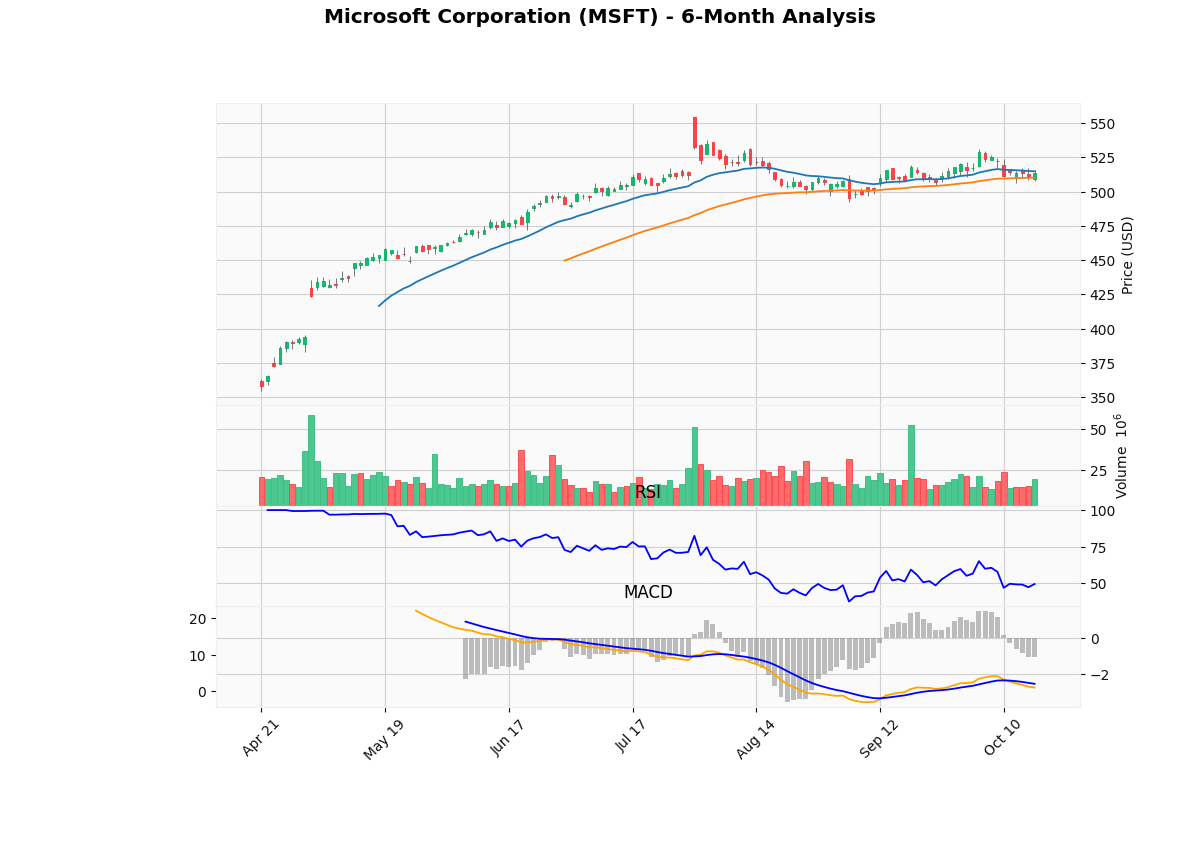

In [18]:
# Cell 6: Run the Agent
run_finsight_agent("Give me a comprehensive analysis of Microsoft (MSFT)")

In [19]:
# Cell 7: Check the Agent's Memory
print("--- Agent's Long-Term Memory ---")
if not AGENT_MEMORY:
    print("No lessons learned yet.")
else:
    for i, lesson in enumerate(AGENT_MEMORY):
        print(f"Lesson {i+1}: {lesson}")

--- Agent's Long-Term Memory ---
Lesson 1: When a visual asset is generated, always dedicate a section to interpret its insights, connecting them to the broader textual analysis, and ensure all interpretations, especially financial inferences, are explicitly backed by data or clearly stated as analytical conclusions.
Lesson 2: Ensure all analytical claims and interpretations are directly and explicitly supported by the provided data, and provide clear context for all financial metrics presented.


In [32]:
# Cell 6: Run the Agent
run_finsight_agent("How does Apple (AAPL) compare to its competitors?")

## 🕵️ FinSight Analysis for: "How does Apple (AAPL) compare to its competitors?"

Injecting initial prompt with memory:
Here are lessons from past analyses to help you improve:
- When a crucial data point cannot be fetched, explicitly state that the analysis cannot be completed, explain *why* that data is essential, and what impact its absence has on the overall analysis.
- When an analysis cannot be completed due to data limitations, clearly explain the problem and proactively suggest alternative analyses or next steps to the user.
- When a tool indicates limitations or failure, provide context if possible and proactively suggest alternative analytical approaches or workarounds to fulfill the user's underlying objective.

**User Query:** How does Apple (AAPL) compare to its competitors?

🤖 Calling Tool: `get_peer_companies` with arguments: {'ticker_symbol': 'AAPL'}
 specialist: fetching peers for AAPL...
 Tool Output: [{"symbol": "AXIL", "companyName": "AXIL Brands, Inc.", "price": 6.88, "mktCap": 46472680}, {"symbol": "FEBO", "companyName": "Fenbo Holdings Limited

---

###  drafting analysis...


--- Starting Evaluation Loop ---
Evaluator's Critique:
<critique>
No notes. This analysis is excellent and ready to publish.
</critique>

<lesson>
Beyond simply presenting data, synthesize key observations and proactively offer logical next steps for deeper analysis.
</lesson>
📚 New Lesson Learned: Beyond simply presenting data, synthesize key observations and proactively offer logical next steps for deeper analysis.
✅ Evaluator approved draft. Publishing as-is.


---

## 💡 FinSight AI Analysis

**Peer Companies for Apple (AAPL):**

Here's a list of companies identified as peers or competitors to Apple, along with their current price and market capitalization:

*   **AXIL Brands, Inc. (AXIL):** Price: $6.88, Market Cap: $46,472,680
*   **Fenbo Holdings Limited Ordinary Shares (FEBO):** Price: $0.75, Market Cap: $8,296,875
*   **Foxx Development Holdings Inc. (FOXX):** Price: $4.08, Market Cap: $27,664,836
*   **GoPro, Inc. (GPRO):** Price: $2.01, Market Cap: $318,183,000
*   **Emerson Radio Corp. (MSN):** Price: $0.4702, Market Cap: $9,894,255
*   **Algorhythm Holdings, Inc. (RIME):** Price: $2.18, Market Cap: $5,481,418
*   **Turtle Beach Corporation (TBCH):** Price: $15.07, Market Cap: $298,486,005
*   **Universal Electronics Inc. (UEIC):** Price: $4.34, Market Cap: $57,882,445
*   **Wearable Devices Ltd. (WLDS):** Price: $2.98, Market Cap: $2,681,362
*   **UTime Limited (WTO):** Price: $0.07, Market Cap: $252,280

**Comparison Notes:**

This list provides a snapshot of companies identified as peers. However, it's important to note that the market capitalization of Apple is significantly larger than all of these companies, indicating a vast difference in scale and market dominance. A deeper comparison would require analyzing financial fundamentals, technical indicators, and market sentiment for each of these companies against Apple, which was not explicitly requested in this query.

If you would like a more detailed comparison focusing on specific financial metrics, technical analysis, or news sentiment for Apple against one or more of these peers, please let me know.

Disclaimer: This is an AI-generated analysis and is for informational purposes only. It does not constitute investment advice.

In [33]:
run_finsight_agent("What are the technicals for TSLA?")

## 🕵️ FinSight Analysis for: "What are the technicals for TSLA?"

Injecting initial prompt with memory:
Here are lessons from past analyses to help you improve:
- When a crucial data point cannot be fetched, explicitly state that the analysis cannot be completed, explain *why* that data is essential, and what impact its absence has on the overall analysis.
- When an analysis cannot be completed due to data limitations, clearly explain the problem and proactively suggest alternative analyses or next steps to the user.
- When a tool indicates limitations or failure, provide context if possible and proactively suggest alternative analytical approaches or workarounds to fulfill the user's underlying objective.
- Beyond simply presenting data, synthesize key observations and proactively offer logical next steps for deeper analysis.

**User Query:** What are the technicals for TSLA?

🤖 Calling Tool: `get_technical_analysis` with arguments: {'ticker_symbol': 'TSLA'}
 specialist: fetching technicals for TSLA...
 Tool Output: {"ticker": "TSLA", "last_price": 

---

###  drafting analysis...


--- Starting Evaluation Loop ---
Evaluator's Critique:
<critique>
- The overall summary presents a purely bullish outlook, but the MACD section explicitly notes a "weakening of bullish momentum or a potential bearish crossover." The summary should acknowledge this conflicting signal to provide a more nuanced and balanced initial perspective, rather than waiting until the MACD details.
- While the MACD interpretation is correct, the analysis could further synthesize the information by explaining how this "weakening momentum" from the MACD potentially tempers or contrasts with the strong bullish signals from the EMAs, rather than just listing them separately.
</critique>

<lesson>
Always synthesize potentially conflicting technical indicators into the overall summary to provide a balanced and comprehensive market view, rather than presenting them as isolated points.
</lesson>
📚 New Lesson Learned: Always synthesize potentially conflicting technical indicators into the overall summary to

### refining draft...

---

## 💡 FinSight AI Analysis

Here is the refined technical analysis for TSLA:

**Overall Summary:** While TSLA exhibits strong bullish signals based on its exponential moving averages, indicating upward trends in both the short and long term, the MACD suggests a potential weakening of bullish momentum, which could temper the overall positive outlook.

**Technical Outlook:**
*   **Last Price:** The last traded price for TSLA was $439.31.
*   **RSI (14-day):** The Relative Strength Index is 56.76. An RSI above 50 generally indicates that a stock is experiencing stronger buying pressure than selling pressure, though it is not yet in overbought territory (typically above 70).
*   **MACD:** The MACD line is 12.02, while the MACD signal line is 16.01. The MACD line is currently below the signal line, suggesting a recent weakening of bullish momentum or a potential bearish crossover if the gap widens. This softening momentum indicated by MACD provides a counterpoint to the strong trend signals from the EMAs, suggesting that while the established trend is up, its immediate strength might be waning.
*   **Exponential Moving Averages (EMA):**
    *   The short-term EMA (20-day) is 426.99, indicating a **Bullish** short-term trend as the price is above this average.
    *   The long-term EMA (50-day) is 396.99, also indicating a **Bullish** long-term trend as the price is above this average. The price being above both EMAs confirms strong upward momentum.

**Next Steps:** To get a more complete picture, you might consider examining volatility indicators like Bollinger Bands or analyzing candlestick patterns for further insights into price action and potential reversals, especially given the mixed signals from MACD and EMAs.

Disclaimer: This is an AI-generated analysis and is for informational purposes only. It does not constitute investment advice.